# 02 — R/B Ratio Threshold Cloud Detection

## Executive Summary
**Method:** Classical red-to-blue (R/B) ratio threshold (Long et al. 2006).

**Physics:** Clear sky scatters blue light (Rayleigh) → R/B < 1. Clouds are
white/grey (Mie scattering) → R/B ≈ 1. Threshold at R/B ≥ threshold classifies cloud.

**Daytime only** — R/B ratio is physically meaningless at night (no Rayleigh scattering).

**Pipeline:**
1. Validate threshold visually on sample images
2. Tune threshold against ACS_WSI ground truth (different camera — reference only)
3. **Tune threshold against Warsaw GT masks (our camera, daytime — primary calibration)**
4. Run on all daytime pilot images → time series
5. Seasonal and diurnal analysis

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

from skycamera.config import CX, CY, R, CSV_DIR, PLOTS_DIR, FULL_RAW_DIR, CF_MAX_ZENITH_DEG
from skycamera.io import load_image, build_image_index, load_acs_wsi_dataset, load_acs_wsi_pair
from skycamera.preprocessing import (
    build_circular_mask, build_zenith_weight_map, weighted_cf, _infer_dome_params,
)
from skycamera.threshold import cloud_fraction_rb_threshold, run_on_index

RAW_ROOT = FULL_RAW_DIR   # data/full_raw/ — full year, thinned to 30-min intervals
ACS_ROOT = Path('D:/MOJE/DATA_SCIENCE/SKYCAMERA/ACS_WSI-v1.0.0')

CSV_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Build dome mask and zenith weight map once (pilot camera resolution)
# Use any image from full_raw for resolution reference
_sample_path = next(FULL_RAW_DIR.rglob('*.jpg'))
_s = load_image(_sample_path)
dome_mask = build_circular_mask(_s.shape[0], _s.shape[1], CX, CY, R)
zenith_weights = build_zenith_weight_map(_s.shape[0], _s.shape[1], CX, CY, R, CF_MAX_ZENITH_DEG)
print(f'Dome mask: {dome_mask.sum():,} valid pixels')
print(f'Zenith weight map: max_zenith={CF_MAX_ZENITH_DEG}°  '
      f'non-zero pixels={int((zenith_weights > 0).sum()):,}')
INDEX_CSV = CSV_DIR / "image_index.csv"

Dome mask: 2,762,359 valid pixels
Zenith weight map: max_zenith=70.0°  non-zero pixels=1,672,145


## 1. Visual validation on three sample images

Red overlay = classified cloud, blue overlay = classified sky.

January: CF = 1.000
June: CF = 0.147
November: CF = 1.000


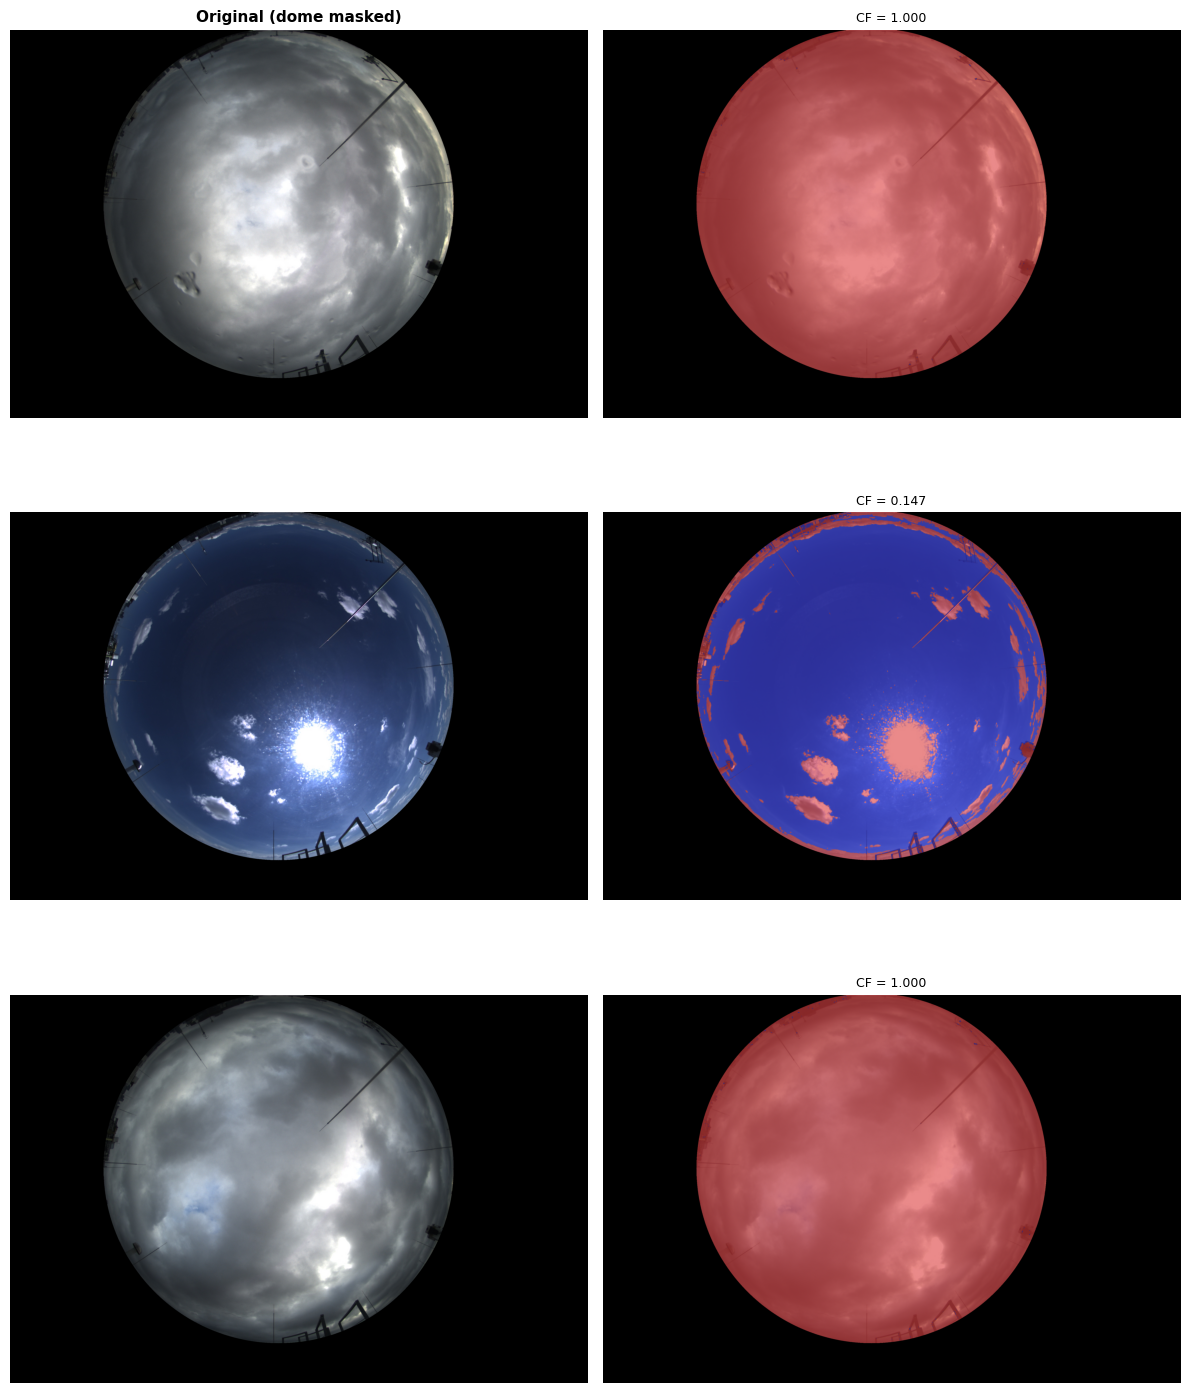

In [2]:
SAMPLES = {
    'January':  RAW_ROOT / '2024-01-15' / '2024_01_15__12_04_51.jpg',
    'June':     RAW_ROOT / '2024-06-15' / '2024_06_15__12_00_31.jpg',
    'November': RAW_ROOT / '2024-11-15' / '2024_11_15__12_00_34.jpg',
}
THRESHOLD = 0.6

fig, axes = plt.subplots(len(SAMPLES), 2, figsize=(12, 5 * len(SAMPLES)))
for ax_row, title in zip(axes[0], ['Original (dome masked)', 'R/B classification (red=cloud, blue=sky)']):
    ax_row.set_title(title, fontsize=11, fontweight='bold')

for row, (label, fpath) in enumerate(SAMPLES.items()):
    img = load_image(fpath)
    cf, debug = cloud_fraction_rb_threshold(img, dome_mask, threshold=THRESHOLD)
    masked = img.copy(); masked[~dome_mask] = 0
    axes[row][0].imshow(masked); axes[row][0].set_ylabel(label, fontsize=10); axes[row][0].axis('off')
    axes[row][1].imshow(debug); axes[row][1].set_title(f'CF = {cf:.3f}', fontsize=9); axes[row][1].axis('off')
    print(f'{label}: CF = {cf:.3f}')

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rb_threshold_samples.png', bbox_inches='tight', dpi=100)
plt.show()

## 2. Threshold tuning on ACS_WSI ground truth

Sweep threshold 0.40–0.90 on all 77 ACS_WSI pairs (area-weighted GT CF).
**Note:** ACS_WSI uses a different camera than the Warsaw pilot — treat this as a reference baseline.
The primary threshold calibration is in section 3 which uses our own Warsaw GT masks.

In [3]:
df_acs = load_acs_wsi_dataset(ACS_ROOT)

# Load all ACS_WSI images + area-weighted GT CF once
acs_imgs, acs_gt_cf, acs_weight_maps = [], [], []
for _, row in tqdm(df_acs.iterrows(), total=len(df_acs), desc='Loading ACS_WSI'):
    img, gt_mask = load_acs_wsi_pair(row['image_path'], row['mask_path'])
    # Infer dome geometry from this mask (ACS_WSI has its own camera intrinsics)
    cx_, cy_, r_ = _infer_dome_params(gt_mask)
    w_map = build_zenith_weight_map(gt_mask.shape[0], gt_mask.shape[1], cx_, cy_, r_, CF_MAX_ZENITH_DEG)
    gt_cf = weighted_cf(gt_mask, w_map)
    acs_imgs.append(img)
    acs_gt_cf.append(gt_cf)
    acs_weight_maps.append(w_map)

acs_gt_cf = np.array(acs_gt_cf)
print(f'Loaded {len(acs_imgs)} ACS_WSI pairs  |  GT CF: mean={np.nanmean(acs_gt_cf):.3f}')

Loading ACS_WSI:   0%|          | 0/77 [00:00<?, ?it/s]

Loaded 77 ACS_WSI pairs  |  GT CF: mean=0.597


In [4]:
thresholds = np.arange(0.40, 0.91, 0.05)
mae_per_threshold = []

for thr in thresholds:
    pred_cfs = []
    for img, w_map in zip(acs_imgs, acs_weight_maps):
        h, w = img.shape[:2]
        full_mask = np.ones((h, w), dtype=bool)
        cf, _ = cloud_fraction_rb_threshold(img, full_mask, threshold=thr, weights=w_map)
        pred_cfs.append(cf)
    pred_arr = np.array(pred_cfs)
    valid = ~np.isnan(pred_arr) & ~np.isnan(acs_gt_cf)
    mae = float(np.mean(np.abs(pred_arr[valid] - acs_gt_cf[valid])))
    mae_per_threshold.append(mae)
    print(f'threshold={thr:.2f}  MAE={mae:.4f}')

best_thr = thresholds[np.argmin(mae_per_threshold)]
best_mae = min(mae_per_threshold)
print(f'\nBest threshold: {best_thr:.2f}  (MAE={best_mae:.4f})')

threshold=0.40  MAE=0.4027
threshold=0.45  MAE=0.3823
threshold=0.50  MAE=0.3523
threshold=0.55  MAE=0.3240
threshold=0.60  MAE=0.2833
threshold=0.65  MAE=0.2316
threshold=0.70  MAE=0.1926
threshold=0.75  MAE=0.1518
threshold=0.80  MAE=0.1246
threshold=0.85  MAE=0.1186
threshold=0.90  MAE=0.1306

Best threshold: 0.85  (MAE=0.1186)


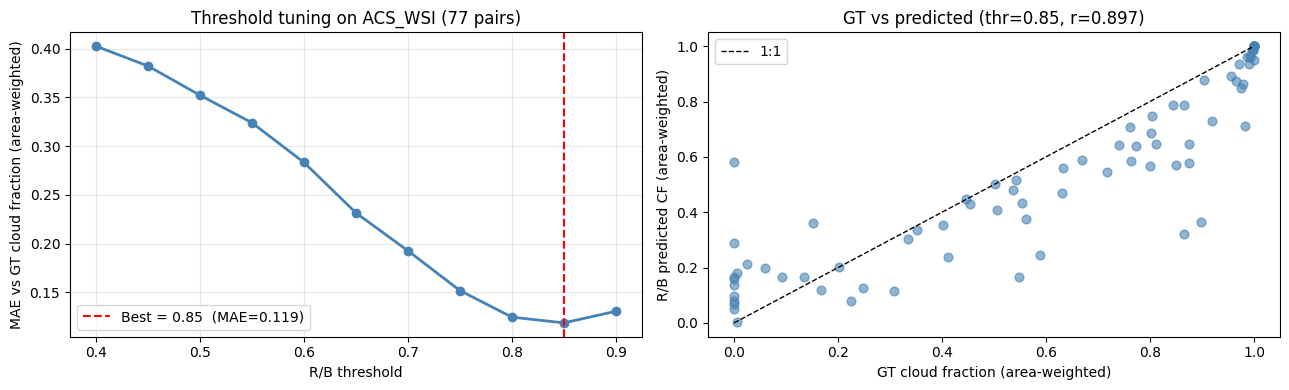

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, mae_per_threshold, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_thr, color='red', linestyle='--', linewidth=1.5,
                label=f'Best = {best_thr:.2f}  (MAE={best_mae:.3f})')
axes[0].set_xlabel('R/B threshold')
axes[0].set_ylabel('MAE vs GT cloud fraction (area-weighted)')
axes[0].set_title('Threshold tuning on ACS_WSI (77 pairs)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: best threshold predictions vs GT
pred_best = []
for img, w_map in zip(acs_imgs, acs_weight_maps):
    h, w = img.shape[:2]
    cf, _ = cloud_fraction_rb_threshold(img, np.ones((h, w), dtype=bool), threshold=best_thr, weights=w_map)
    pred_best.append(cf)
pred_best = np.array(pred_best)

valid_mask = ~np.isnan(pred_best) & ~np.isnan(acs_gt_cf)
axes[1].scatter(acs_gt_cf[valid_mask], pred_best[valid_mask], alpha=0.6, color='steelblue', s=40)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='1:1')
r = np.corrcoef(acs_gt_cf[valid_mask], pred_best[valid_mask])[0, 1]
axes[1].set_xlabel('GT cloud fraction (area-weighted)')
axes[1].set_ylabel('R/B predicted CF (area-weighted)')
axes[1].set_title(f'GT vs predicted (thr={best_thr:.2f}, r={r:.3f})')
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rb_threshold_tuning.png', bbox_inches='tight', dpi=100)
plt.show()

## 3. Threshold tuning on Warsaw GT masks (primary calibration)

Tune on our own daytime Warsaw pilot images with manually-labelled GT masks.
Same camera, same location, same lighting as inference — this is the preferred threshold source.
Only images flagged `is_daytime=True` in the index are used.

Falls back to the ACS_WSI best threshold if fewer than 5 daytime Warsaw GT masks are available.

In [6]:
from skycamera.config import MASKS_MANUAL_DIR, FULL_RAW_DIR
from skycamera.labelling import LABEL_CLOUD, LABEL_SKY, load_existing_mask

MIN_WARSAW = 5

# Load or build image index to get daytime stems
if not INDEX_CSV.exists():
    df_index_tmp = build_image_index(RAW_ROOT, apply_daytime_filter=True)
    df_index_tmp.to_csv(INDEX_CSV, index=False)
else:
    df_index_tmp = pd.read_csv(INDEX_CSV, parse_dates=["timestamp"])
    df_index_tmp["path"] = df_index_tmp["path"].apply(Path)

daytime_stems = set(
    df_index_tmp[df_index_tmp["is_daytime"]]["path"].apply(lambda p: Path(p).stem)
)

# Load each image ONCE and precompute the R/B ratio array inside the dome.
warsaw_rb_ratios = []
warsaw_weights   = []
warsaw_gt_cf     = []

gt_pngs = sorted(p for p in MASKS_MANUAL_DIR.glob("*_GT.png")
                 if p.name != "default_ignore.png")

for mask_path in gt_pngs:
    stem = mask_path.stem.replace("_GT", "")
    if stem not in daytime_stems:
        continue
    raw_candidates = list(FULL_RAW_DIR.rglob(stem + ".jpg"))
    if not raw_candidates:
        continue
    try:
        img = load_image(raw_candidates[0])
        gt_mask = load_existing_mask(mask_path)
        binary = np.full(gt_mask.shape, 255, dtype=np.uint8)
        binary[gt_mask == LABEL_SKY]   = 0
        binary[gt_mask == LABEL_CLOUD] = 1
        gt_cf_val = weighted_cf(binary, zenith_weights)
        if np.isnan(gt_cf_val):
            continue

        r = img[:,:,0].astype(np.float32)
        b = img[:,:,2].astype(np.float32)
        valid = dome_mask & (b > 0) & (zenith_weights > 0)
        rb    = r[valid] / b[valid]
        w     = zenith_weights[valid]

        warsaw_rb_ratios.append(rb)
        warsaw_weights.append(w)
        warsaw_gt_cf.append(gt_cf_val)
    except Exception as e:
        print(f"Warning: {mask_path.name}: {e}")

warsaw_gt_cf = np.array(warsaw_gt_cf)
print(f"Warsaw daytime GT masks found: {len(warsaw_gt_cf)}")
if len(warsaw_gt_cf) > 0:
    print(f"GT CF: mean={warsaw_gt_cf.mean():.3f}  std={warsaw_gt_cf.std():.3f}")

if len(warsaw_gt_cf) < MIN_WARSAW:
    print(f"Only {len(warsaw_gt_cf)} masks — need {MIN_WARSAW} for reliable tuning."
          f" Falling back to ACS_WSI threshold: {best_thr:.2f}")
    final_thr = best_thr
    best_thr_warsaw = best_thr
    best_mae_warsaw = float("nan")
else:
    thresholds_w = np.arange(0.40, 0.91, 0.05)
    mae_warsaw = []

    for thr in thresholds_w:
        pred_cfs = []
        for rb, w in zip(warsaw_rb_ratios, warsaw_weights):
            cloud_w = w[rb >= thr].sum()
            total_w = w.sum()
            pred_cfs.append(cloud_w / total_w if total_w > 0 else float("nan"))
        pred_arr = np.array(pred_cfs)
        ok = ~np.isnan(pred_arr) & ~np.isnan(warsaw_gt_cf)
        mae_warsaw.append(float(np.mean(np.abs(pred_arr[ok] - warsaw_gt_cf[ok]))))
        print(f"threshold={thr:.2f}  MAE={mae_warsaw[-1]:.4f}")

    best_thr_warsaw = thresholds_w[np.argmin(mae_warsaw)]
    best_mae_warsaw = min(mae_warsaw)
    final_thr = best_thr_warsaw
    print(f"\nBest Warsaw threshold: {best_thr_warsaw:.2f}  (MAE={best_mae_warsaw:.4f})")
    print(f"ACS_WSI best was {best_thr:.2f} — difference: {abs(best_thr_warsaw - best_thr):.2f}")

Warsaw daytime GT masks found: 458
GT CF: mean=0.540  std=0.431
threshold=0.40  MAE=0.3966
threshold=0.45  MAE=0.3002
threshold=0.50  MAE=0.2073
threshold=0.55  MAE=0.1342
threshold=0.60  MAE=0.1153
threshold=0.65  MAE=0.1253
threshold=0.70  MAE=0.1527
threshold=0.75  MAE=0.1955
threshold=0.80  MAE=0.2525
threshold=0.85  MAE=0.2913
threshold=0.90  MAE=0.3264

Best Warsaw threshold: 0.60  (MAE=0.1153)
ACS_WSI best was 0.85 — difference: 0.25


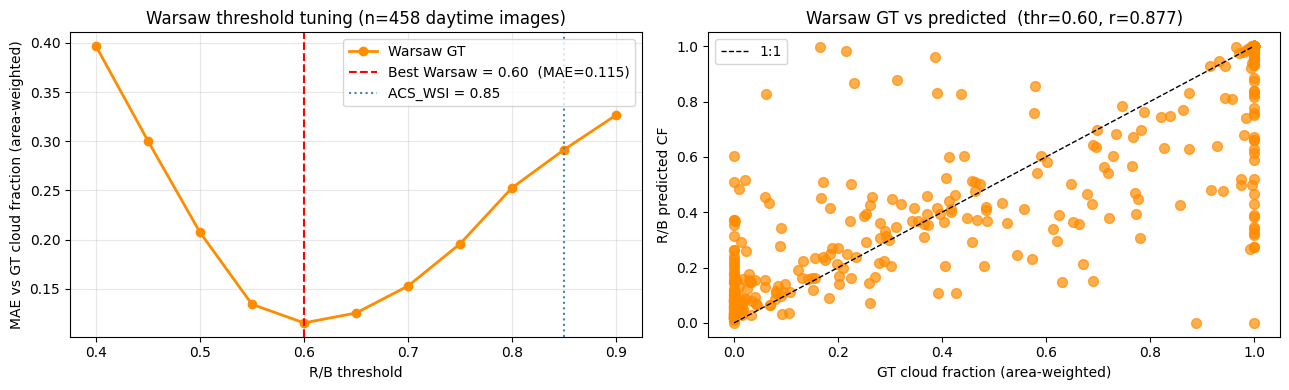

Final threshold for time-series run: 0.60


In [7]:
if len(warsaw_rb_ratios) >= MIN_WARSAW:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(thresholds_w, mae_warsaw, "o-", color="darkorange", linewidth=2, label="Warsaw GT")
    axes[0].axvline(best_thr_warsaw, color="red", linestyle="--", linewidth=1.5,
                    label=f"Best Warsaw = {best_thr_warsaw:.2f}  (MAE={best_mae_warsaw:.3f})")
    axes[0].axvline(best_thr, color="steelblue", linestyle=":", linewidth=1.5,
                    label=f"ACS_WSI = {best_thr:.2f}")
    axes[0].set_xlabel("R/B threshold")
    axes[0].set_ylabel("MAE vs GT cloud fraction (area-weighted)")
    axes[0].set_title(f"Warsaw threshold tuning (n={len(warsaw_rb_ratios)} daytime images)")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Recompute predictions at best threshold using cached rb arrays
    pred_best_w = np.array([
        w[rb >= best_thr_warsaw].sum() / w.sum() if w.sum() > 0 else float("nan")
        for rb, w in zip(warsaw_rb_ratios, warsaw_weights)
    ])
    ok = ~np.isnan(pred_best_w) & ~np.isnan(warsaw_gt_cf)
    r_w = np.corrcoef(warsaw_gt_cf[ok], pred_best_w[ok])[0,1] if ok.sum() > 2 else float("nan")
    axes[1].scatter(warsaw_gt_cf[ok], pred_best_w[ok], alpha=0.7, color="darkorange", s=50)
    axes[1].plot([0,1],[0,1],"k--", linewidth=1, label="1:1")
    axes[1].set_xlabel("GT cloud fraction (area-weighted)")
    axes[1].set_ylabel("R/B predicted CF")
    axes[1].set_title(f"Warsaw GT vs predicted  (thr={best_thr_warsaw:.2f}, r={r_w:.3f})")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "rb_threshold_tuning_warsaw.png", bbox_inches="tight", dpi=100)
    plt.show()

print(f"Final threshold for time-series run: {final_thr:.2f}")

## 4. Run on all daytime pilot images

Uses `final_thr` — the Warsaw-tuned threshold when ≥5 GT masks exist, else ACS_WSI fallback.
Results cached to `outputs/csv/cf_rb_threshold.csv`.

In [8]:
CF_CSV = CSV_DIR / 'cf_rb_threshold.csv'
INDEX_CSV = CSV_DIR / 'image_index.csv'

# Load or rebuild image index
if INDEX_CSV.exists():
    df_index = pd.read_csv(INDEX_CSV, parse_dates=['timestamp'])
    df_index['path'] = df_index['path'].apply(Path)
else:
    from skycamera.io import build_image_index
    df_index = build_image_index(RAW_ROOT, apply_daytime_filter=True)
    df_index.to_csv(INDEX_CSV, index=False)

print(f'Index: {len(df_index):,} images  |  daytime: {df_index["is_daytime"].sum():,}')

if CF_CSV.exists():
    print('Loading cached R/B results...')
    df_cf = pd.read_csv(CF_CSV, parse_dates=['timestamp'])
else:
    print(f'Running R/B threshold (thr={final_thr:.2f}) on all daytime images...')
    df_cf = run_on_index(df_index, dome_mask, threshold=final_thr, weights=zenith_weights)
    df_cf.to_csv(CF_CSV, index=False)
    print(f'Saved -> {CF_CSV}')

print(f'\nResults: {len(df_cf):,} images')
print(f'CF: mean={df_cf["cloud_fraction"].mean():.3f}  std={df_cf["cloud_fraction"].std():.3f}')
df_cf.head()

Index: 17,145 images  |  daytime: 9,637
Running R/B threshold (thr=0.60) on all daytime images...
Saved -> D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\outputs\csv\cf_rb_threshold.csv

Results: 9,276 images
CF: mean=0.633  std=0.410


,timestamp,cloud_fraction,month,hour
0,2024-01-01 12:00:41,1.0,1,12
1,2024-01-01 12:31:23,1.0,1,12
2,2024-01-01 13:27:40,1.0,1,13
3,2024-01-01 13:58:20,1.0,1,13
4,2024-01-01 14:29:02,1.0,1,14


## 5. Time series plot

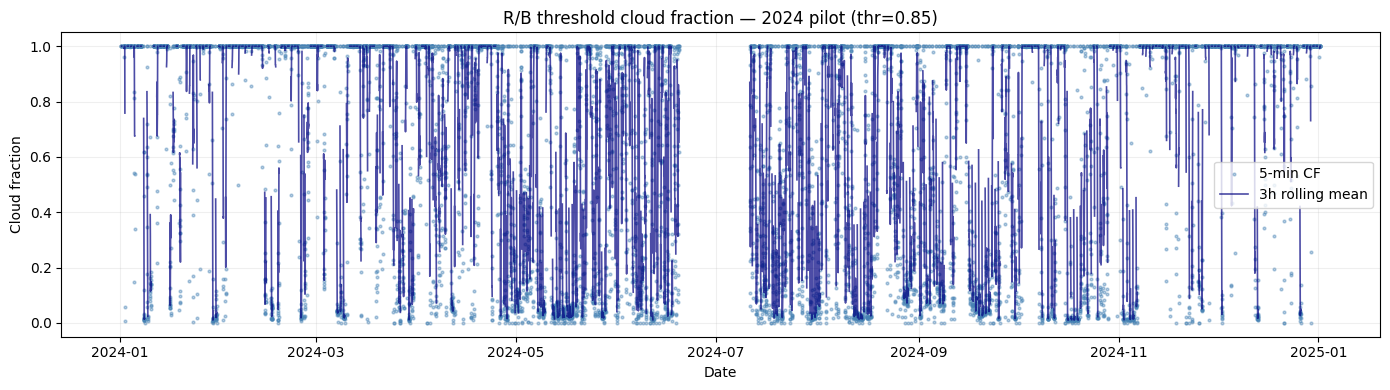

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(df_cf['timestamp'], df_cf['cloud_fraction'],
           s=4, alpha=0.4, color='steelblue', label='5-min CF')

# 3-hour rolling mean for readability
df_cf_sorted = df_cf.set_index('timestamp').sort_index()
rolling = df_cf_sorted['cloud_fraction'].rolling('3h', min_periods=5).mean()
ax.plot(rolling.index, rolling.values, color='navy', linewidth=1.2,
        alpha=0.7, label='3h rolling mean')

ax.set_ylabel('Cloud fraction')
ax.set_xlabel('Date')
ax.set_title(f'R/B threshold cloud fraction — 2024 pilot (thr={best_thr:.2f})')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rb_cf_timeseries.png', bbox_inches='tight', dpi=100)
plt.show()

## 6. Monthly and diurnal patterns

C:\Users\szymo\AppData\Local\Temp\ipykernel_21780\540819124.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(monthly_groups, labels=month_names,


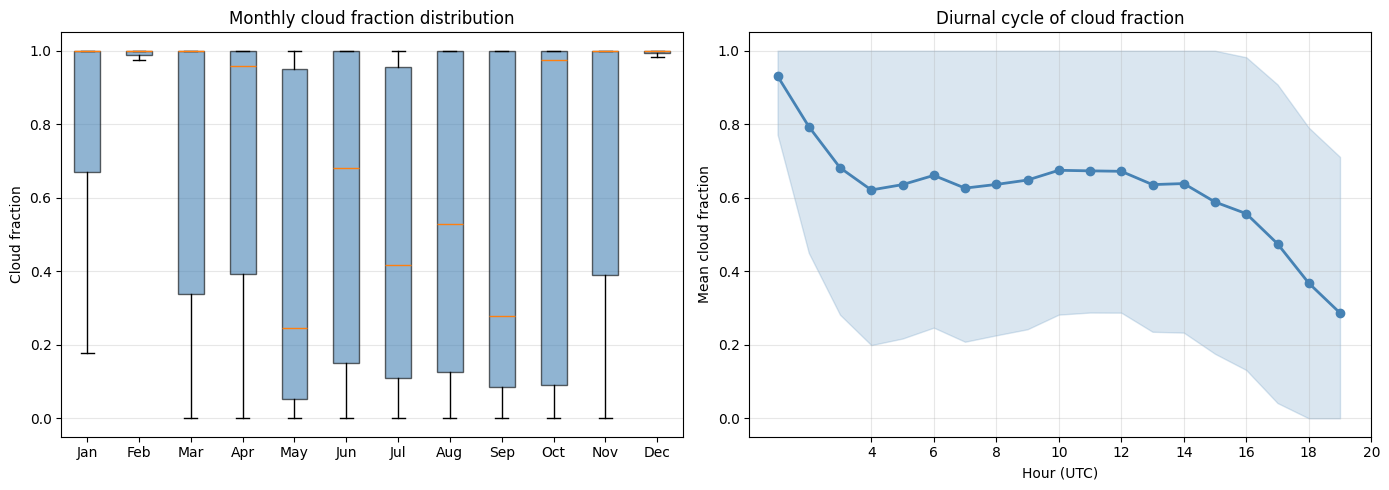

In [10]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly boxplot
monthly_groups = [df_cf[df_cf['month'] == m]['cloud_fraction'].values
                  for m in range(1, 13)]
bp = axes[0].boxplot(monthly_groups, labels=month_names,
                     patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[0].set_ylabel('Cloud fraction')
axes[0].set_title('Monthly cloud fraction distribution')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Diurnal cycle (mean CF per hour)
diurnal = df_cf.groupby('hour')['cloud_fraction'].agg(['mean', 'std'])
axes[1].plot(diurnal.index, diurnal['mean'], 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(diurnal.index,
                     (diurnal['mean'] - diurnal['std']).clip(0),
                     (diurnal['mean'] + diurnal['std']).clip(0, 1),
                     alpha=0.2, color='steelblue')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Mean cloud fraction')
axes[1].set_title('Diurnal cycle of cloud fraction')
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xticks(range(4, 22, 2))
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(PLOTS_DIR / 'rb_cf_monthly_diurnal.png', bbox_inches='tight', dpi=100)
plt.show()

## 7. Summary statistics

In [11]:
print('=== R/B Threshold Method Summary ===')
print(f'Threshold used       : {final_thr:.2f} (Warsaw-tuned; ACS_WSI fallback if <5 GT masks)')
print(f'ACS_WSI tuning MAE   : {best_mae:.4f}')
print(f'ACS_WSI Pearson r    : {float(np.corrcoef(acs_gt_cf[~np.isnan(acs_gt_cf)], pred_best[~np.isnan(acs_gt_cf)])[0,1]):.4f}')
print()
print(f'Pilot images processed : {len(df_cf):,}')
print(f'Mean CF                : {df_cf["cloud_fraction"].mean():.3f}')
print(f'Fraction overcast (>0.8): {(df_cf["cloud_fraction"] > 0.8).mean()*100:.1f}%')
print(f'Fraction clear    (<0.2): {(df_cf["cloud_fraction"] < 0.2).mean()*100:.1f}%')
print()
print('Monthly mean CF:')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(df_cf.groupby('month')['cloud_fraction'].mean().rename(index=
      dict(enumerate(month_names, 1))).round(3).to_string())

=== R/B Threshold Method Summary ===
Threshold used       : 0.60 (Warsaw-tuned; ACS_WSI fallback if <5 GT masks)
ACS_WSI tuning MAE   : 0.1186
ACS_WSI Pearson r    : 0.8967

Pilot images processed : 9,276
Mean CF                : 0.633
Fraction overcast (>0.8): 53.4%
Fraction clear    (<0.2): 27.9%

Monthly mean CF:
month
Jan    0.788
Feb    0.837
Mar    0.720
Apr    0.710
May    0.439
Jun    0.582
Jul    0.489
Aug    0.549
Sep    0.463
Oct    0.617
Nov    0.753
Dec    0.862
